# Домашняя работа 4. Визуальный анализ и качество данных

Датасет — объявления Airbnb в Нью-Йорке из проекта [Inside Airbnb](https://insideairbnb.com/get-the-data/), фиксированная версия файла `listings.csv`, приложенная к заданию. Цены указаны в долларах США за ночь.

Порядок работы: знакомство с данными → пропуски → визуальный анализ → дубликаты → выбросы → итоговые выводы.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 30)

## 1. Загрузка и знакомство с данными

In [2]:
df = pd.read_csv("listings.csv")

print("Строк и столбцов:", df.shape)
print()
print("Столбцы:")
print(list(df.columns))

Строк и столбцов: (30555, 19)

Столбцы:
['id', 'name', 'host_id', 'host_profile_id', 'host_name', 'neighbourhood_group', 'neighbourhood', 'latitude', 'longitude', 'room_type', 'price', 'minimum_nights', 'number_of_reviews', 'last_review', 'reviews_per_month', 'calculated_host_listings_count', 'availability_365', 'number_of_reviews_ltm', 'license']


In [3]:
df.dtypes

id                                  int64
name                                  str
host_id                           float64
host_profile_id                   float64
host_name                             str
neighbourhood_group                   str
neighbourhood                         str
latitude                          float64
longitude                         float64
room_type                             str
price                             float64
minimum_nights                    float64
number_of_reviews                   int64
last_review                           str
reviews_per_month                 float64
calculated_host_listings_count    float64
availability_365                    int64
number_of_reviews_ltm               int64
license                               str
dtype: object

In [4]:
df.head()

,id,name,host_id,host_profile_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm,license
0,1279666081527148590,"The Broome, Deluxe Queen",NaN,NaN,NaN,Manhattan,SoHo,40.721354,-73.999346,Private room,468.0,1.0,3,2026-02-08,0.57,NaN,338,3,NaN
1,1543683559947083167,"M Social Hotel New York Downtown, Deluxe king ...",NaN,NaN,NaN,Manhattan,Financial District,40.710028,-74.011360,Private room,188.0,1.0,23,2026-05-04,3.37,NaN,265,23,NaN
2,1559522395930572140,"ModernHaus SoHo, SoHo deluxe king",NaN,NaN,NaN,Manhattan,SoHo,40.722680,-74.004830,Private room,431.0,1.0,3,2026-02-22,0.54,NaN,273,3,NaN
3,1665948589959289542,Superior 1-bedroom apartment w/ den & 2 queens,NaN,NaN,NaN,Manhattan,Financial District,40.707529,-74.006188,Private room,257.0,1.0,1,2026-06-10,1.00,NaN,360,1,NaN
4,1394234603510215650,Chic boutique hotel stay | Ameritania Hotel,NaN,NaN,NaN,Manhattan,Midtown,40.764025,-73.982833,Private room,170.0,1.0,168,2026-06-02,12.23,NaN,365,165,NaN


In [5]:
df.describe().round(2)

,id,host_id,host_profile_id,latitude,longitude,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm
count,3.055500e+04,3.025900e+04,2.991000e+04,30555.00,30555.00,21797.00,30553.00,30555.00,21939.00,30259.00,30555.00,30555.00
mean,6.252408e+17,2.672815e+15,1.469574e+18,40.73,-73.95,278.33,26.64,32.41,0.88,55.89,186.79,4.62
std,6.182099e+17,6.705743e+16,2.417061e+16,0.06,0.06,528.54,27.46,79.23,1.98,174.25,139.38,19.19
min,2.539000e+03,1.678000e+03,1.462506e+18,40.50,-74.25,5.00,1.00,0.00,0.01,1.00,0.00,0.00
25%,3.043632e+07,2.069159e+07,1.462882e+18,40.69,-73.98,98.00,30.00,0.00,0.09,1.00,29.50,0.00
50%,6.700833e+17,1.074344e+08,1.465524e+18,40.73,-73.96,176.00,30.00,4.00,0.28,2.00,209.00,0.00
75%,1.164525e+18,3.948700e+08,1.469572e+18,40.76,-73.93,304.00,30.00,29.00,1.00,12.00,319.00,2.00
max,1.707075e+18,1.704453e+18,1.706707e+18,40.91,-73.71,30973.00,1124.00,4502.00,115.63,955.00,365.00,1225.00


**1. Что является одной строкой датасета?**
Одна строка — одно объявление (listing) на Airbnb в Нью-Йорке: у каждой строки свой `id`, название, хозяин, расположение, тип жилья, цена за ночь и статистика отзывов. В таблице 30 555 объявлений и 19 столбцов.

**2. Числовые и категориальные признаки.**
- Числовые: `price` (цена за ночь, $), `minimum_nights` (минимальный срок аренды), `number_of_reviews` (всего отзывов), `reviews_per_month` (отзывов в месяц), `availability_365` (доступных дней в году), `number_of_reviews_ltm` (отзывов за последние 12 месяцев), `calculated_host_listings_count` (объявлений у хозяина). `latitude` и `longitude` — числовые координаты. `id`, `host_id`, `host_profile_id` хранятся числами, но это идентификаторы: считать по ним статистики бессмысленно (поэтому их строки в `describe()` не несут смысла).
- Категориальные: `neighbourhood_group` (5 районов Нью-Йорка), `neighbourhood` (конкретный квартал), `room_type` (тип жилья), `license` (номер регистрации или статус). Текстовые: `name`, `host_name`. `last_review` — дата, сейчас хранится строкой.

**3. Наиболее полезные столбцы для анализа.**
- `price` — главный показатель объявления; именно её обычно хотят объяснить или сравнить.
- `room_type` — целая квартира, комната или место в общей комнате — это принципиально разные предложения с разной ценой.
- `neighbourhood_group` / `neighbourhood` — расположение сильно влияет на цену (Манхэттен против других районов).
- `number_of_reviews` / `reviews_per_month` — показатели спроса и активности объявления.
- `availability_365` — показывает, активно ли объявление сдаётся; как выяснится ниже, он тесно связан с пропусками в цене.

## 2. Пропущенные значения

### 2.1. Где есть пропуски

Для каждого столбца считаем количество пропусков и их долю в процентах, оставляем только столбцы с пропусками и сортируем по убыванию.

In [6]:
missing = pd.DataFrame({
    "missing_count": df.isna().sum(),
    "missing_percent": (df.isna().mean() * 100).round(2),
})

missing = missing[missing["missing_count"] > 0].sort_values("missing_count", ascending=False)
missing

,missing_count,missing_percent
license,25269,82.70
price,8758,28.66
last_review,8616,28.20
reviews_per_month,8616,28.20
host_profile_id,645,2.11
host_name,645,2.11
calculated_host_listings_count,296,0.97
host_id,296,0.97
minimum_nights,2,0.01
name,1,0.00


**Где пропусков больше всего.** Больше всего пропусков в `license` (около 83%), затем в `price` (около 29%), `last_review` и `reviews_per_month` (по 28.2%, причём одинаковое количество — 8 616). Небольшие доли пропусков в данных о хозяине (`host_name`, `host_profile_id` — 2.1%, `host_id`, `calculated_host_listings_count` — около 1%), а в `minimum_nights` и `name` — единичные пропуски.

**Одинаково ли они критичны?** Нет.
- Пропуски в **`price`** самые критичные: это ключевой признак для анализа, и без него объявление нельзя включить в анализ цен. Их много (почти треть), и заполнить их «правильным» значением нельзя.
- Пропуски в **`reviews_per_month`** и **`last_review`**, скорее всего, не ошибка, а отсутствие отзывов — это проверим в 2.2.
- **`license`** — пропуск означает, что номер регистрации не указан. Для анализа цен и отзывов этот столбец вторичен.
- Пропуски в **`host_name`**, **`name`**, **`minimum_nights`** немногочисленны и на основные выводы почти не влияют.

### 2.2. Причина пропусков в `reviews_per_month`

Гипотеза: `reviews_per_month` пуст у объявлений, у которых вообще нет отзывов (`number_of_reviews == 0`) — тогда «отзывов в месяц» посчитать не из чего. Проверяем таблицей частот.

In [7]:
pd.crosstab(
    df["reviews_per_month"].isna(),
    df["number_of_reviews"] == 0,
    rownames=["reviews_per_month пропущен"],
    colnames=["number_of_reviews == 0"],
)

number_of_reviews == 0,False,True
reviews_per_month пропущен,,
False,21939,0
True,0,8616


In [8]:
print("Пропуски в reviews_per_month и last_review совпадают по строкам:",
      (df["reviews_per_month"].isna() == df["last_review"].isna()).all())
print("Минимальное непропущенное значение reviews_per_month:", df["reviews_per_month"].min())

Пропуски в reviews_per_month и last_review совпадают по строкам: True
Минимальное непропущенное значение reviews_per_month: 0.01


**Вывод.** Гипотеза подтверждается полностью: все 8 616 пропусков в `reviews_per_month` приходятся ровно на объявления с `number_of_reviews == 0`, и наоборот — у всех объявлений с хотя бы одним отзывом значение заполнено. В тех же строках пуст и `last_review`. Значит, это не потерянные данные, а логичное отсутствие значения: у объявления ещё не было отзывов. Минимальное заполненное значение — 0.01, то есть нулей в столбце нет: «ноль отзывов в месяц» записан как пропуск.

Дополнительно посмотрим, с чем связаны пропуски в `price` — это поможет выбрать стратегию для неё.

In [9]:
pd.crosstab(
    df["price"].isna(),
    df["availability_365"] == 0,
    rownames=["price пропущена"],
    colnames=["availability_365 == 0"],
)

availability_365 == 0,False,True
price пропущена,,
False,21796,1
True,1958,6800


Из 8 758 объявлений без цены 6 800 (около 78%) имеют `availability_365 == 0` — они недоступны для бронирования ни в один день года, то есть фактически неактивны. И наоборот: почти у всех недоступных объявлений цена не указана. Значит, пропуск цены в основном означает «объявление сейчас не сдаётся», а не случайную потерю данных.

### 2.3. Стратегии обработки

Работаем с копией `df_clean`, чтобы исходная таблица осталась нетронутой.

| Столбец | Решение | Почему |
|---|---|---|
| `reviews_per_month` | заполнить **0** | как показано в 2.2, пропуск возникает только при нуле отзывов, то есть истинное значение — 0 отзывов в месяц |
| `host_name` | заполнить меткой **`"Unknown"`** | это текст, который не участвует в расчётах; метка сохраняет строки и честно показывает, что имя неизвестно |
| `price` | **не заполнять**; для анализа цен использовать только строки с известной ценой | пропусков почти 29%, и они связаны с неактивными объявлениями. Подстановка медианы создала бы тысячи искусственных одинаковых цен и исказила бы распределение, а удаление строк из всей таблицы потеряло бы данные по другим признакам |

`last_review` оставляем пустым: дату последнего отзыва для объявления без отзывов придумать нельзя.

In [10]:
df_clean = df.copy()

# reviews_per_month: пропуск = нет отзывов, значит 0 отзывов в месяц
df_clean["reviews_per_month"] = df_clean["reviews_per_month"].fillna(0)

# host_name: текстовая метка вместо пропуска
df_clean["host_name"] = df_clean["host_name"].fillna("Unknown")

print("Пропусков в reviews_per_month после обработки:", df_clean["reviews_per_month"].isna().sum())
print("Пропусков в host_name после обработки:", df_clean["host_name"].isna().sum())
print("Объявлений с меткой 'Unknown':", (df_clean["host_name"] == "Unknown").sum())

Пропусков в reviews_per_month после обработки: 0
Пропусков в host_name после обработки: 0
Объявлений с меткой 'Unknown': 645


In [11]:
# price: отдельная таблица только с известной ценой — для анализа цен и выбросов
df_price = df_clean[df_clean["price"].notna()].copy()

print("Всего объявлений:", len(df_clean))
print("Объявлений с известной ценой:", len(df_price))
print("Доля объявлений, попавших в анализ цен:", round(len(df_price) / len(df_clean) * 100, 1), "%")

Всего объявлений: 30555
Объявлений с известной ценой: 21797
Доля объявлений, попавших в анализ цен: 71.3 %


**Итог обработки.** `reviews_per_month` и `host_name` больше не содержат пропусков, при этом ни одна строка не удалена. Для анализа цены дальше используется `df_price` — 21 797 объявлений (около 71%) с известной ценой. Важно помнить, что эта выборка смещена в сторону активных объявлений: выводы о ценах относятся именно к ним.

## 3. Визуальный анализ

### 3.1. Распределение цены

`price` — непрерывный числовой признак, поэтому строим гистограмму. Из-за очень дорогих объявлений на полном диапазоне почти всё сливается в один столбец у нуля, поэтому рядом показываем то же распределение до 99-го перцентиля — 1% самых дорогих объявлений на правом графике не отображается.

In [12]:
print(df_price["price"].describe().round(2))
print()
print("99-й перцентиль цены:", df_price["price"].quantile(0.99))
print("Доля объявлений дешевле 300 $:", round((df_price["price"] <= 300).mean() * 100, 1), "%")

count    21797.00
mean       278.33
std        528.54
min          5.00
25%         98.00
50%        176.00
75%        304.00
max      30973.00
Name: price, dtype: float64

99-й перцентиль цены: 1702.2400000000052
Доля объявлений дешевле 300 $: 74.7 %


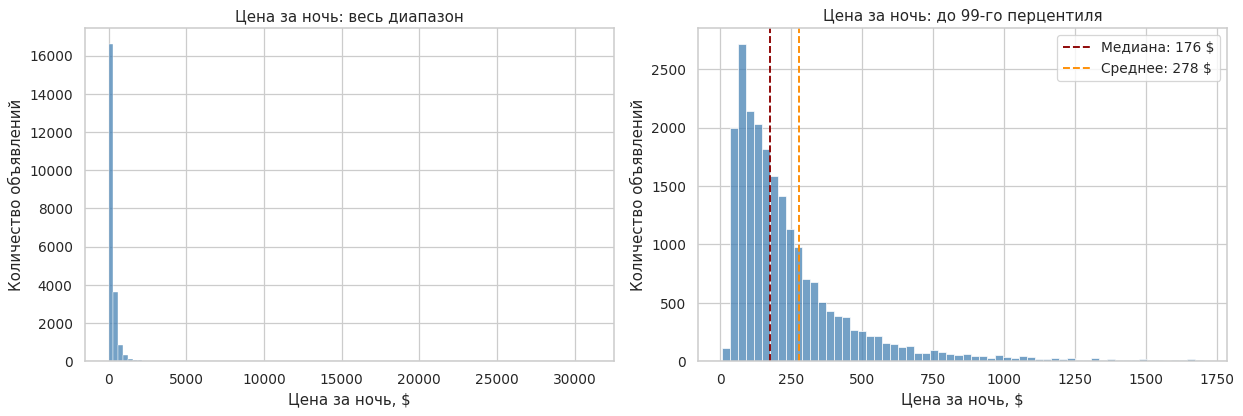

In [13]:
price_p99 = df_price["price"].quantile(0.99)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))

sns.histplot(data=df_price, x="price", bins=100, color="steelblue", ax=axes[0])
axes[0].set_title("Цена за ночь: весь диапазон")
axes[0].set_xlabel("Цена за ночь, $")
axes[0].set_ylabel("Количество объявлений")

sns.histplot(data=df_price[df_price["price"] <= price_p99], x="price", bins=60, color="steelblue", ax=axes[1])
axes[1].axvline(df_price["price"].median(), color="darkred", linestyle="--",
                label=f"Медиана: {df_price['price'].median():.0f} $")
axes[1].axvline(df_price["price"].mean(), color="darkorange", linestyle="--",
                label=f"Среднее: {df_price['price'].mean():.0f} $")
axes[1].set_title("Цена за ночь: до 99-го перцентиля")
axes[1].set_xlabel("Цена за ночь, $")
axes[1].set_ylabel("Количество объявлений")
axes[1].legend()

plt.tight_layout()
plt.show()

**Вывод.** Основная масса объявлений стоит примерно от 100 до 300 $ за ночь: половина цен лежит между 98 и 304 $, медиана — 176 $, около 75% объявлений не дороже 300 $. Распределение сильно несимметрично — длинный «хвост» вправо, из-за которого среднее (278 $) заметно больше медианы. Есть объявления, резко отличающиеся от большинства: 99-й перцентиль около 1 700 $, а максимум — почти 31 000 $ за ночь.

### 3.2. Распределение по типу жилья

`room_type` — категориальный признак с четырьмя значениями, поэтому подходит столбчатая диаграмма с количеством объявлений. Используем весь `df_clean`: тип жилья известен у всех объявлений.

In [14]:
room_counts = df_clean["room_type"].value_counts()
room_share = (df_clean["room_type"].value_counts(normalize=True) * 100).round(1)
pd.DataFrame({"count": room_counts, "percent": room_share})

,count,percent
room_type,,
Entire home/apt,16808,55.0
Private room,13009,42.6
Hotel room,520,1.7
Shared room,218,0.7


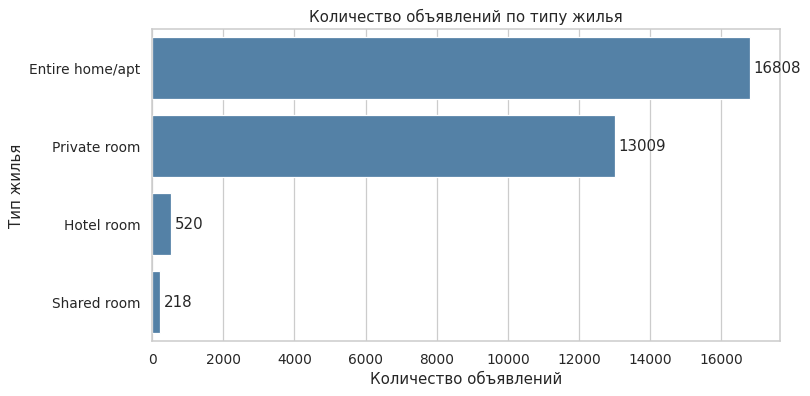

In [15]:
plt.figure(figsize=(9, 4.5))
ax = sns.countplot(data=df_clean, y="room_type", order=room_counts.index, color="steelblue")
ax.bar_label(ax.containers[0], padding=3)
plt.title("Количество объявлений по типу жилья")
plt.xlabel("Количество объявлений")
plt.ylabel("Тип жилья")
plt.show()

**Вывод.** Чаще всего сдаются целые квартиры и дома (`Entire home/apt`) — 55% объявлений, на втором месте отдельные комнаты (`Private room`) — около 43%. Две категории редкие: гостиничные номера (`Hotel room`, 1.7%) и места в общей комнате (`Shared room`, 0.7%). При сравнении групп нужно помнить, что выводы по этим двум категориям основаны на небольшом числе объявлений.

### 3.3. Цена по типу жилья

Сравниваем числовой признак между группами категориального, причём не только по среднему, но и по распределению внутри групп — для этого подходит **boxplot**: он показывает медиану, квартили, разброс и выбросы. Цены различаются на порядки, поэтому ось Y сделана логарифмической — иначе «ящики» сжимаются у нуля из-за объявлений за десятки тысяч долларов.

In [16]:
df_price.groupby("room_type")["price"].describe()[["count", "25%", "50%", "75%", "max"]].round(0)

,count,25%,50%,75%,max
room_type,,,,,
Entire home/apt,11537.0,147.0,223.0,357.0,30973.0
Hotel room,480.0,273.0,447.0,771.0,14864.0
Private room,9588.0,67.0,107.0,208.0,12279.0
Shared room,192.0,42.0,54.0,148.0,2967.0


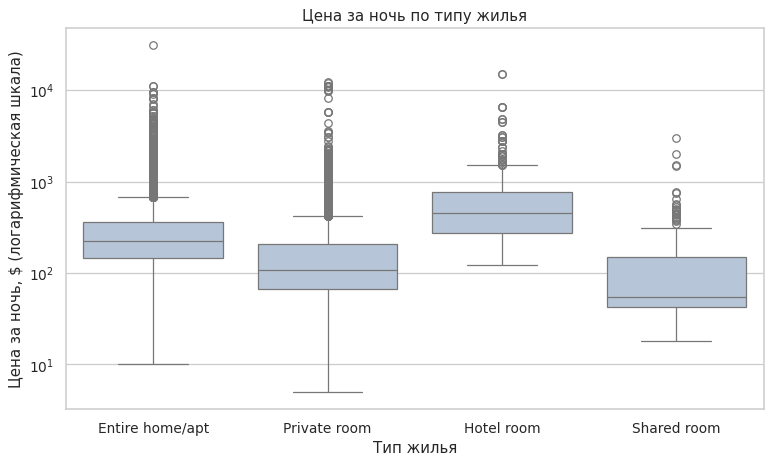

In [17]:
room_order = ["Entire home/apt", "Private room", "Hotel room", "Shared room"]

plt.figure(figsize=(10, 5.5))
sns.boxplot(data=df_price, x="room_type", y="price", order=room_order, color="lightsteelblue")
plt.yscale("log")
plt.title("Цена за ночь по типу жилья")
plt.xlabel("Тип жилья")
plt.ylabel("Цена за ночь, $ (логарифмическая шкала)")
plt.show()

**Вывод.** Самые дорогие по медиане — гостиничные номера (около 447 $), затем целые квартиры (223 $); отдельная комната стоит примерно вдвое дешевле квартиры (медиана 107 $), а место в общей комнате — дешевле всего (54 $). Внутри каждой группы разброс очень большой, и у всех типов есть выбросы вверх: даже среди отдельных комнат встречаются цены выше 10 000 $, поэтому сравнивать группы по среднему было бы некорректно — медиана и квартили здесь надёжнее.

### 3.4. Связь признаков отзывов

Два числовых признака — `number_of_reviews` (всего отзывов) и `reviews_per_month` (отзывов в месяц) — показываем диаграммой рассеяния. Оба признака имеют длинный хвост вправо, поэтому обе оси логарифмические. Берём только объявления, у которых есть хотя бы один отзыв: у остальных оба значения равны нулю, а ноль нельзя показать на логарифмической оси.

In [18]:
reviewed = df_clean[df_clean["number_of_reviews"] > 0]

print("Объявлений с отзывами:", len(reviewed))
print("Корреляция Пирсона:", round(reviewed["number_of_reviews"].corr(reviewed["reviews_per_month"]), 2))
print("Корреляция Спирмена:", round(reviewed["number_of_reviews"].corr(reviewed["reviews_per_month"], method="spearman"), 2))

Объявлений с отзывами: 21939
Корреляция Пирсона: 0.72
Корреляция Спирмена: 0.81


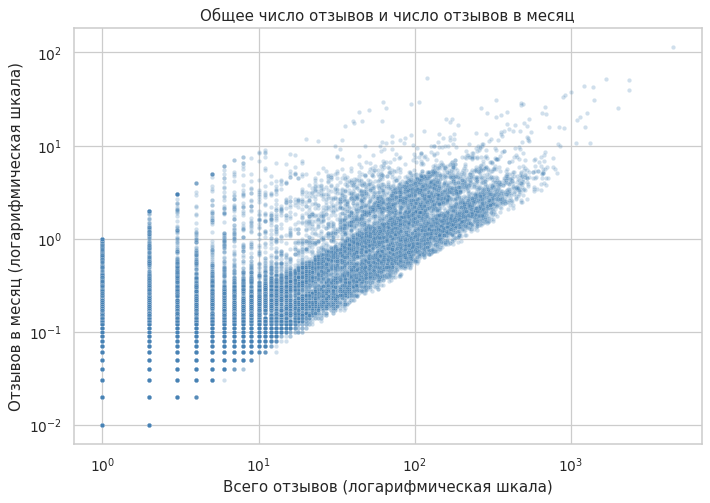

In [19]:
plt.figure(figsize=(9, 6))
sns.scatterplot(data=reviewed, x="number_of_reviews", y="reviews_per_month", alpha=0.25, s=12, color="steelblue")
plt.xscale("log")
plt.yscale("log")
plt.title("Общее число отзывов и число отзывов в месяц")
plt.xlabel("Всего отзывов (логарифмическая шкала)")
plt.ylabel("Отзывов в месяц (логарифмическая шкала)")
plt.show()

**Вывод.** Связь положительная и довольно сильная (корреляция Спирмена около 0.81): чем больше у объявления отзывов, тем больше в среднем и отзывов в месяц. Но связь нестрогая — облако точек широкое: `reviews_per_month` зависит ещё и от того, сколько времени объявление существует, поэтому при одном и том же общем числе отзывов «старое» объявление имеет низкую частоту, а новое — высокую. Отдельные объявления набирают десятки отзывов в месяц (максимум — около 116 у хостела), что для многоместного хостела вполне реально.

## 4. Дубликаты

Проверяем полные дубликаты строк и повторы идентификатора `id`.

In [20]:
full_duplicates = df.duplicated().sum()
id_duplicates = df["id"].duplicated().sum()

print("Полных дубликатов строк:", full_duplicates)
print("Повторяющихся значений id:", id_duplicates)

Полных дубликатов строк: 0
Повторяющихся значений id: 0


Дополнительно проверим, есть ли строки, которые совпадают во всём, **кроме** `id`, — то есть потенциальные «скрытые» дубли, опубликованные под разными идентификаторами.

In [21]:
same_except_id = df.drop(columns="id").duplicated()
print("Строк, совпадающих во всём, кроме id (без учёта первого вхождения):", same_except_id.sum())

group_rows = df[df.drop(columns="id").duplicated(keep=False)]
print("Всего строк в таких группах:", len(group_rows))
print("Объявлений с отзывами среди них:", (group_rows["number_of_reviews"] > 0).sum())
print()
print(group_rows["room_type"].value_counts())

Строк, совпадающих во всём, кроме id (без учёта первого вхождения): 70
Всего строк в таких группах: 101
Объявлений с отзывами среди них: 0

room_type
Entire home/apt    70
Private room       29
Hotel room          2
Name: count, dtype: int64


In [22]:
group_rows.sort_values(["host_id", "name"])[
    ["id", "name", "host_id", "room_type", "price", "number_of_reviews", "availability_365"]
].head(8)

,id,name,host_id,room_type,price,number_of_reviews,availability_365
29299,793305335027186680,"Blueground | Clinton Hill, gym, pool & w/d",107434423.0,Entire home/apt,NaN,0,2
29446,806208335662808362,"Blueground | Clinton Hill, gym, pool & w/d",107434423.0,Entire home/apt,NaN,0,2
8588,726679319187119772,"Blueground | FiDi, gym, doorman & w/d, nr Wall St",107434423.0,Entire home/apt,NaN,0,315
15490,727394016312534644,"Blueground | FiDi, gym, doorman & w/d, nr Wall St",107434423.0,Entire home/apt,NaN,0,315
15101,999772794962783206,"Blueground | FiDi, gym, nr Freedom Tower",107434423.0,Entire home/apt,NaN,0,318
21375,999774727861426844,"Blueground | FiDi, gym, nr Freedom Tower",107434423.0,Entire home/apt,NaN,0,318
16318,1381931528540894785,"Blueground | Midtown S, gym, roof, nr Times Sq",107434423.0,Entire home/apt,NaN,0,310
16549,1388975401767294314,"Blueground | Midtown S, gym, roof, nr Times Sq",107434423.0,Entire home/apt,NaN,0,310


**Одинаковы ли «полный дубль строки» и «повторяющийся ID»?** Нет. Полный дубль — это строка, совпадающая с другой во **всех** столбцах; обычно это техническая ошибка (одна запись загружена дважды). Повторяющийся `id` означает, что под одним идентификатором есть несколько записей, которые могут отличаться в других полях — это проблема уникальности ключа. Бывает и наоборот: разные `id` при одинаковом содержимом.

**Нужно ли что-то удалять?** Полных дубликатов и повторов `id` нет, поэтому по результатам основной проверки удалять ничего не нужно. Дополнительно найдено 70 строк, которые совпадают с другими во всём, кроме `id` (101 строка в таких группах): это однотипные объявления одних и тех же хозяев (например, несколько квартир компании Blueground или одинаковые гостиничные номера) с одинаковыми координатами и без единого отзыва. Скорее всего, это отдельные юниты с одинаковым описанием, а не ошибочные копии, поэтому удалять их без дополнительной информации не стоит; но при анализе надо помнить, что они могут немного «размножать» одинаковые значения.

## 5. Выбросы

### 5.1. Выбросы в `price`: визуальный анализ и метод IQR

Сначала смотрим на boxplot цены, затем считаем границы по правилу IQR: всё, что ниже `Q1 − 1.5·IQR` или выше `Q3 + 1.5·IQR`, считается потенциальным выбросом.

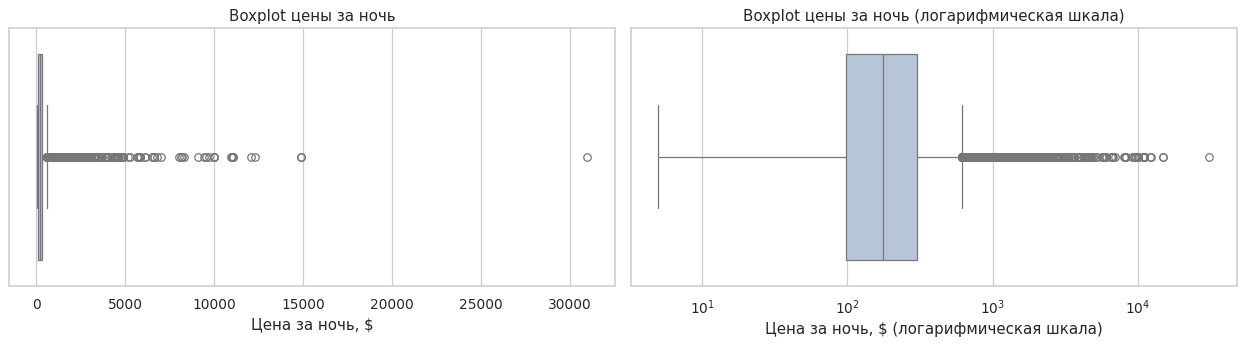

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sns.boxplot(data=df_price, x="price", color="lightsteelblue", ax=axes[0])
axes[0].set_title("Boxplot цены за ночь")
axes[0].set_xlabel("Цена за ночь, $")

sns.boxplot(data=df_price, x="price", color="lightsteelblue", ax=axes[1])
axes[1].set_xscale("log")
axes[1].set_title("Boxplot цены за ночь (логарифмическая шкала)")
axes[1].set_xlabel("Цена за ночь, $ (логарифмическая шкала)")

plt.tight_layout()
plt.show()

In [24]:
q1 = df_price["price"].quantile(0.25)
q3 = df_price["price"].quantile(0.75)
iqr = q3 - q1

lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

price_outliers = df_price[(df_price["price"] < lower_bound) | (df_price["price"] > upper_bound)]

print(f"Q1 = {q1:.0f} $, Q3 = {q3:.0f} $, IQR = {iqr:.0f} $")
print(f"Нижняя граница: {lower_bound:.0f} $")
print(f"Верхняя граница: {upper_bound:.0f} $")
print()
print("Значений за пределами границ:", len(price_outliers))
print("  из них ниже нижней границы:", (df_price["price"] < lower_bound).sum())
print("  из них выше верхней границы:", (df_price["price"] > upper_bound).sum())
print()
print(f"Доля от всего датасета ({len(df)} объявлений): {len(price_outliers) / len(df) * 100:.2f} %")
print(f"Доля от объявлений с известной ценой ({len(df_price)}): {len(price_outliers) / len(df_price) * 100:.2f} %")

Q1 = 98 $, Q3 = 304 $, IQR = 206 $
Нижняя граница: -211 $
Верхняя граница: 613 $

Значений за пределами границ: 1607
  из них ниже нижней границы: 0
  из них выше верхней границы: 1607

Доля от всего датасета (30555 объявлений): 5.26 %
Доля от объявлений с известной ценой (21797): 7.37 %


**Вывод.** На обычном boxplot «ящик» сжат у нуля, а справа тянется длинная цепочка выбросов до ~31 000 $. По правилу IQR верхняя граница — 613 $ за ночь; нижняя граница отрицательная (−211 $), поэтому выбросов вниз по этому правилу нет. Выше 613 $ находятся 1 607 объявлений — 5.26% от всего датасета или 7.37% от объявлений с известной ценой. Все выбросы — это слишком дорогие, а не слишком дешёвые объявления.

### 5.2. Интерпретация самых дорогих объявлений

In [25]:
df_price.sort_values("price", ascending=False)[
    ["name", "neighbourhood_group", "room_type", "price", "minimum_nights",
     "number_of_reviews", "availability_365"]
].head(10)

,name,neighbourhood_group,room_type,price,minimum_nights,number_of_reviews,availability_365
13652,"260 West Broadway, Unit 1/2C",Manhattan,Entire home/apt,30973.0,30.0,0,365
21515,Opulent Midtown Retreat with White-Gloved Service,Manhattan,Hotel room,14864.0,1.0,0,344
22690,"Presidential Suite Park View King Bed, The Pierre",Manhattan,Hotel room,14864.0,1.0,0,345
7587,Sunny Luxury Bedroom Guest Bathroom,Manhattan,Private room,12279.0,30.0,3,83
7390,Enormous Chrysler-View Bedroom/Bath,Manhattan,Private room,12078.0,30.0,1,83
3423,"Eighth House, State of the Art NYC Venue",Manhattan,Entire home/apt,11062.0,30.0,0,365
8298,North Gallery Café,Manhattan,Entire home/apt,11062.0,30.0,0,365
30163,Near Times Square | Jazz Nights. Bar + Dining,Manhattan,Private room,10986.0,1.0,0,278
12457,Empire State Views | Bar. Live Jazz + City Views,Manhattan,Private room,10986.0,1.0,0,293
29942,Walk to Empire State | Gym. Live Jazz. Bar On-...,Manhattan,Private room,10986.0,1.0,0,278


**Являются ли они обязательно ошибками?** Нет. Среди самых дорогих есть вполне правдоподобные объявления: например, президентский люкс отеля The Pierre на Манхэттене за 14 864 $ за ночь — для люксовых номеров в центре Нью-Йорка это реальная цена. Но есть и подозрительные: квартира за 30 973 $ за ночь с минимальным сроком 30 ночей и нулём отзывов или отдельная комната за 12 279 $ — похоже на ошибку ввода или цену за весь месяц, указанную как цену за ночь. Многие из самых дорогих объявлений не имеют ни одного отзыва, то есть цену нельзя подтвердить реальными бронированиями.

**Можно ли удалить все выбросы только по правилу IQR?** Нет. IQR — формальное правило, которое лишь указывает на значения, далёкие от типичных. При таком сильно скошенном распределении под него попадает более 1 600 объявлений, в том числе реальные дорогие квартиры и гостиничные номера — при удалении мы потеряли бы весь сегмент премиального жилья и исказили бы выводы о рынке. Решение по каждому типу выбросов нужно принимать с учётом смысла данных: проверять явно невозможные значения, смотреть на тип жилья, район, отзывы и цель анализа.

### 5.3. Ещё один признак: `minimum_nights`

Минимальный срок аренды может содержать необычные значения (например, сроки в годы). Смотрим распределение, самые частые значения и самые большие сроки. На гистограмме ось Y логарифмическая, чтобы были видны и редкие большие значения.

In [26]:
print(df_clean["minimum_nights"].describe().round(1))
print()
print("Самые частые значения minimum_nights:")
print(df_clean["minimum_nights"].value_counts().head(8))
print()
print("Объявлений с минимальным сроком меньше 30 ночей:", (df_clean["minimum_nights"] < 30).sum())
print("Объявлений с минимальным сроком больше 365 ночей:", (df_clean["minimum_nights"] > 365).sum())

count    30553.0
mean        26.6
std         27.5
min          1.0
25%         30.0
50%         30.0
75%         30.0
max       1124.0
Name: minimum_nights, dtype: float64

Самые частые значения minimum_nights:
minimum_nights
30.0    23802
1.0      4143
2.0       899
3.0       445
31.0      331
90.0      145
5.0       127
4.0       126
Name: count, dtype: int64

Объявлений с минимальным сроком меньше 30 ночей: 5836
Объявлений с минимальным сроком больше 365 ночей: 17


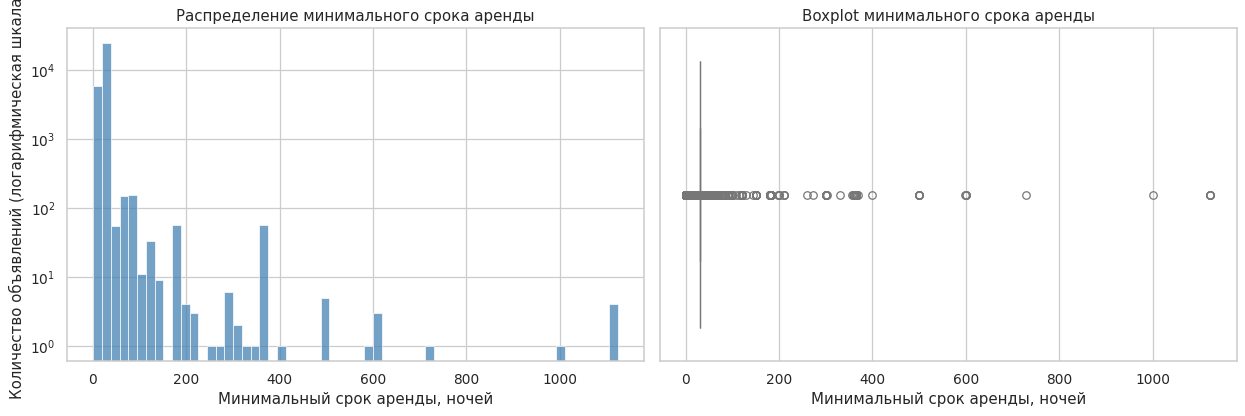

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))

sns.histplot(data=df_clean, x="minimum_nights", bins=60, color="steelblue", ax=axes[0])
axes[0].set_yscale("log")
axes[0].set_title("Распределение минимального срока аренды")
axes[0].set_xlabel("Минимальный срок аренды, ночей")
axes[0].set_ylabel("Количество объявлений (логарифмическая шкала)")

sns.boxplot(data=df_clean, x="minimum_nights", color="lightsteelblue", ax=axes[1])
axes[1].set_title("Boxplot минимального срока аренды")
axes[1].set_xlabel("Минимальный срок аренды, ночей")

plt.tight_layout()
plt.show()

In [28]:
df_clean[df_clean["minimum_nights"] > 365].sort_values("minimum_nights", ascending=False)[
    ["name", "room_type", "price", "minimum_nights", "number_of_reviews"]
]

,name,room_type,price,minimum_nights,number_of_reviews
7498,NYC Astoria LaGuardia #2 Wide PrivateRoom King...,Private room,NaN,1124.0,21
28282,NYC Astoria LaGuardia #5 Small PrivateRoom Kin...,Private room,NaN,1124.0,8
24813,"Large 1 bdrm, River views!",Entire home/apt,NaN,1124.0,8
28376,NYC Astoria LaGuardia #4 Very Tiny Room Single...,Private room,NaN,1124.0,9
884,Private Bedrooms (2) in Washington Heights.,Private room,NaN,1000.0,1
30242,"3915 Room""Shine"" Own Bathroom 2 Persons Only NYC",Private room,NaN,729.0,0
26833,Lovely 4BR/4BA + Private Garden Williamsburg,Entire home/apt,NaN,600.0,0
26987,"Lovely, Furnished Studio w/ Laundry + Garden",Entire home/apt,NaN,600.0,0
26854,LARGE DUPLEX-3BR/3BA Williamsburg Townhouse+GA...,Entire home/apt,NaN,600.0,0
27006,Affordable Small Private Room in Manhattan,Private room,NaN,599.0,217


**Вывод.** Распределение очень необычное: около 78% объявлений имеют минимальный срок ровно 30 ночей. Это похоже не на «выброс», а на реакцию рынка на правила Нью-Йорка, ограничивающие краткосрочную аренду (сдача на срок меньше 30 дней требует регистрации — поэтому многие хозяева ставят минимум 30 ночей). Потенциальные выбросы — 17 объявлений с минимальным сроком больше года, вплоть до 1 124 ночей (около трёх лет). Часть из них реальна (долгосрочная аренда комнат, 500–600 ночей), но значение 1 124 ночи встречается у четырёх объявлений, три из которых принадлежат одному хозяину («NYC Astoria LaGuardia #2, #4, #5»), и выглядит как техническое значение-заглушка, а не реальный срок. У всех этих 17 объявлений нет цены, то есть они неактивны.

Отдельно видно ограничение метода IQR: у `minimum_nights` первый и третий квартили оба равны 30, поэтому IQR = 0, и boxplot формально считает выбросом **любое** значение, отличное от 30, — даже обычную аренду на 1–2 ночи. Это ещё один аргумент не удалять выбросы механически.

## 6. Итоговые выводы

1. **Цена сильно скошена вправо.** Типичное объявление стоит 100–300 $ за ночь (медиана 176 $), но хвост тянется до десятков тысяч долларов, поэтому для описания цен корректнее использовать медиану и квартили, а не среднее. Цена сильно зависит от типа жилья: медиана гостиничного номера около 447 $, целой квартиры — 223 $, комнаты — 107 $, места в общей комнате — 54 $.

2. **Пропуски в данных имеют понятные причины.** Пропуски в `reviews_per_month` и `last_review` в точности совпадают с объявлениями без отзывов, поэтому `reviews_per_month` корректно заполнить нулём. Пропуски цены (почти 29%) в основном связаны с неактивными объявлениями (`availability_365 == 0`), поэтому цену заполнять не стоит — выводы о ценах относятся к активным объявлениям.

3. **Выбросы по IQR нельзя удалять механически.** Правило IQR отмечает 1 607 объявлений дороже 613 $ (5.3% датасета), но среди них много реального премиального жилья. Подозрительными выглядят отдельные значения — цены выше 10 000 $ у объявлений без отзывов и `minimum_nights = 1124`, — и их нужно проверять по отдельности.

4. **Рынок подстроен под правило 30 дней.** Почти 4 из 5 объявлений имеют минимальный срок ровно 30 ночей, то есть большая часть предложения в этой версии данных — среднесрочная, а не посуточная аренда.

5. **Формально дубликатов нет, но качество данных неидеально.** Полных дублей и повторов `id` не найдено, однако есть группы одинаковых объявлений под разными `id` и около 300 гостиничных объявлений без данных о хозяине — это стоит учитывать при подсчётах по хозяевам.